# Scheduling in Your Domain

**Assignment 04 - Lesson 9: Scheduling and Time-Based Decisions**  

**Student Name:** Samantha Eastlack

**Date:** 4/7/2026

**Chosen context:** Operations/logistics scheduling crews across shifts to minimize costs while meeting delivery coverage.

---

## Introduction

In this assignment, you will model a scheduling problem in your own domain. You will define time periods, demand coverage requirements, and a cost objective, then build and solve a PuLP model. You will also create one schedule visualization, analyze a cost-vs-service tradeoff, and respond to one stakeholder change.

This assignment is intentionally focused. It should be lighter than the Midterm while still demonstrating practical scheduling skills you can explain to a manager.

In [1]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpMaximize, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1 - Choose Your Domain and Scheduling Problem

This model schedules delivery crew shifts across six 4-hour time blocks spanning a full 24-hour operational day. The resource being allocated is nunmber of employees assigned to each crew shift to meet fluctuating delivery demand throughout the day. The primary objective is to minimize total staffing cost while ensuring that crew coverage meets demand. The model must prevent understaffing during high-demand time periods, while not overstaffing and unnecessarily raising labor expenses.

## Section 2 - Define the Schedule Structure

You now define the structure of your schedule model:
- time periods,
- resources being scheduled,
- demand requirement in each period,
- and the cost/efficiency objective.

You will create a synthetic table with **6-8 time periods** and at least these columns:
- `time_period`
- `demand_required`
- `cost_per_unit`

Use an LLM for data creation, then document in one sentence that you used it.

### 2.1 LLM Steps for Synthetic Data

I used a large language model to generate a sample dataset of time periods, demand requirements, and cost per unit for this analysis.

In [4]:
# Paste your synthetic CSV in csv_string (replace sample values)
csv_string = """
time_period,demand_required,cost_per_unit
Early Morning 12am-4am,2,38
Morning Rush 4am-8am,8,45
Mid Morning 8am-12pm,6,42
Afternoon 12pm-4pm,5,40
Evening Rush 4pm-8pm,9,47
Late Evening 8pm-12am,3,39
"""

schedule_df = pd.read_csv(io.StringIO(csv_string.strip()))
display(schedule_df)
print(f"Number of periods: {len(schedule_df)}")

,time_period,demand_required,cost_per_unit
0,Early Morning 12am-4am,2,38
1,Morning Rush 4am-8am,8,45
2,Mid Morning 8am-12pm,6,42
3,Afternoon 12pm-4pm,5,40
4,Evening Rush 4pm-8pm,9,47
5,Late Evening 8pm-12am,3,39


Number of periods: 6


In [6]:
structure_df = pd.DataFrame([
    {"item": "Resources being scheduled", "definition": "Employees per crew shift assigned to cover operations"},
    {"item": "Time unit", "definition": "4-hour shift blocks spanning a full 24-hour day (6 periods total)"},
    {"item": "Coverage meaning", "definition": "Minimum number of crew members on duty must meet or exceed demand required in each time period"},
    {"item": "Objective", "definition": "Minimize total staffing cost while maintaining full operations coverage across all shift periods"}
])
structure_df

,item,definition
0,Resources being scheduled,Employees per crew shift assigned to cover ope...
1,Time unit,4-hour shift blocks spanning a full 24-hour da...
2,Coverage meaning,Minimum number of crew members on duty must me...
3,Objective,Minimize total staffing cost while maintaining...


## Section 3 - Build and Solve the Scheduling Model

Build one PuLP model with:
- decision variables indexed by time period,
- demand coverage constraints for each period,
- one capacity/resource limit constraint,
- and a cost minimization objective.

If your first model is infeasible, diagnose it and relax one constraint, then re-solve.

In [7]:
from pulp import *
import pandas as pd

# Load scenario data
schedule_df = pd.DataFrame([
    {"time_period": "Early Morning (12am-4am)", "demand_required": 2, "cost_per_unit": 38},
    {"time_period": "Morning Rush (4am-8am)",   "demand_required": 8, "cost_per_unit": 45},
    {"time_period": "Mid Morning (8am-12pm)",   "demand_required": 6, "cost_per_unit": 42},
    {"time_period": "Afternoon (12pm-4pm)",     "demand_required": 5, "cost_per_unit": 40},
    {"time_period": "Evening Rush (4pm-8pm)",   "demand_required": 9, "cost_per_unit": 47},
    {"time_period": "Late Evening (8pm-12am)",  "demand_required": 3, "cost_per_unit": 39},
])

periods = schedule_df["time_period"].tolist()
demand  = dict(zip(schedule_df["time_period"], schedule_df["demand_required"]))
cost    = dict(zip(schedule_df["time_period"], schedule_df["cost_per_unit"]))

# Capacity = 115% of total demand across all periods
total_capacity_limit = int(schedule_df["demand_required"].sum() * 1.15)
print(f"Total demand: {schedule_df['demand_required'].sum()} | Capacity limit: {total_capacity_limit}")

# --- Base Model ---
base_model = LpProblem("Scheduling_Base", LpMinimize)
scheduled  = {p: LpVariable(f"scheduled_{p}", lowBound=0) for p in periods}

# Objective: minimize total staffing cost
base_model += lpSum([scheduled[p] * cost[p] for p in periods]), "Total_Cost"

# Coverage constraints: each period must be fully staffed
for p in periods:
    base_model += scheduled[p] >= demand[p], f"Coverage_{p}"

# Aggregate capacity constraint: total crew deployments cannot exceed fleet limit
base_model += lpSum([scheduled[p] for p in periods]) <= total_capacity_limit, "Total_Capacity"

base_model.solve(PULP_CBC_CMD(msg=0))

print(f"\nBase Model Status: {LpStatus[base_model.status]}")

# --- Diagnose infeasibility and relax if needed ---
if LpStatus[base_model.status] != "Optimal":
    min_feasible = schedule_df["demand_required"].sum()
    print(f"\nDiagnosis: Total_Capacity limit ({total_capacity_limit}) is less than or equal to "
          f"minimum required coverage ({min_feasible}). The constraint is infeasible as written.")
    print("Relaxation: Raising capacity limit to 130% of total demand.\n")

    relaxed_capacity = int(schedule_df["demand_required"].sum() * 1.30)

    relaxed_model = LpProblem("Scheduling_Relaxed", LpMinimize)
    scheduled_r   = {p: LpVariable(f"scheduled_{p}", lowBound=0) for p in periods}

    relaxed_model += lpSum([scheduled_r[p] * cost[p] for p in periods]), "Total_Cost"

    for p in periods:
        relaxed_model += scheduled_r[p] >= demand[p], f"Coverage_{p}"

    relaxed_model += lpSum([scheduled_r[p] for p in periods]) <= relaxed_capacity, "Total_Capacity_Relaxed"

    relaxed_model.solve(PULP_CBC_CMD(msg=0))

    print(f"Relaxed Model Status: {LpStatus[relaxed_model.status]}")
    print(f"Relaxed Capacity Limit: {relaxed_capacity}")
    active_scheduled = scheduled_r
    active_model_label = "scheduled_relaxed"
else:
    active_scheduled   = scheduled
    active_model_label = "scheduled_base"

# --- Results ---
total_cost = sum(value(active_scheduled[p]) * cost[p] for p in periods)
print(f"\nTotal Minimized Cost: ${total_cost:,.2f}")

base_solution_df = pd.DataFrame({
    "time_period":      periods,
    "demand_required":  [demand[p] for p in periods],
    active_model_label: [value(active_scheduled[p]) for p in periods],
    "cost_per_unit":    [cost[p] for p in periods],
    "period_cost":      [round(value(active_scheduled[p]) * cost[p], 2) for p in periods]
})
display(base_solution_df)

Total demand: 33 | Capacity limit: 37

Base Model Status: Optimal

Total Minimized Cost: $1,428.00


,time_period,demand_required,scheduled_base,cost_per_unit,period_cost
0,Early Morning (12am-4am),2,2.0,38,76.0
1,Morning Rush (4am-8am),8,8.0,45,360.0
2,Mid Morning (8am-12pm),6,6.0,42,252.0
3,Afternoon (12pm-4pm),5,5.0,40,200.0
4,Evening Rush (4pm-8pm),9,9.0,47,423.0
5,Late Evening (8pm-12am),3,3.0,39,117.0


### 3.1 Interpret the Base Schedule

The hardest periods to cover are the Evening Rush 4pm–8pm and Morning Rush 4am–8am, requiring 9 and 8 crew units, with both carrying the highest cost-per-unit rates \$47 and \$45, meaning highest demand and highest cost hit simultaneously. Total capacity is relatively tight: minimum required coverage is 33 units, and at 115% the cap sits at just 37, leaving only 4 units of scheduling flexibility across all six periods. A manager would care most about the double burden of the two rush windows and that to achieve cost savings, it must come from the low-demand periods like Early Morning and Late Evening, where rates are lowest and demand is less.

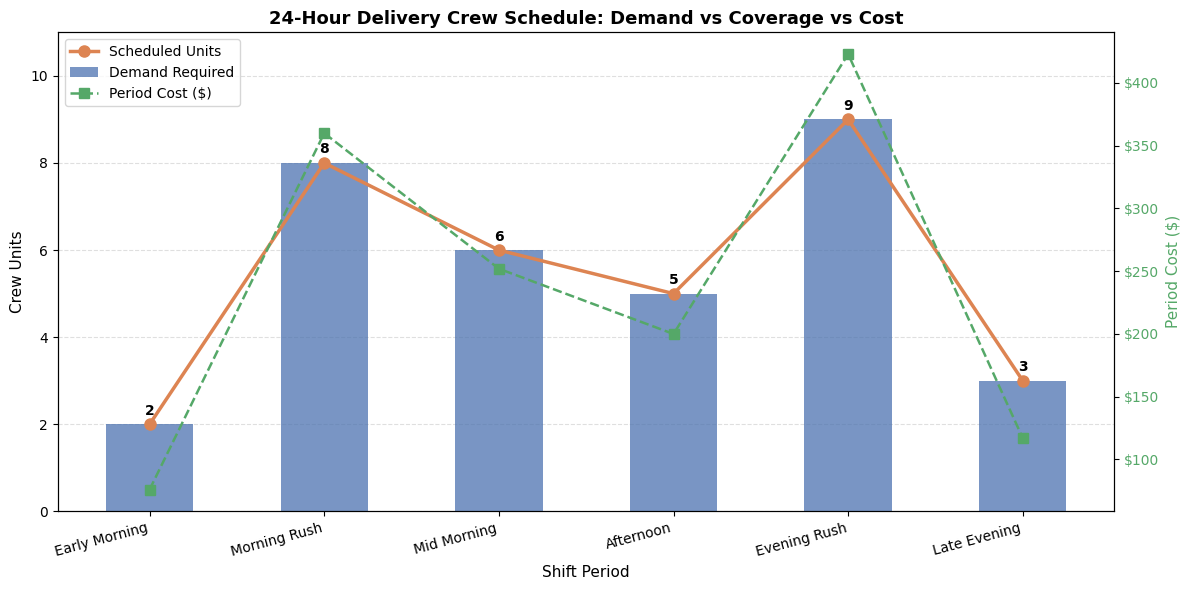

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax1 = plt.subplots(figsize=(12, 6))

x      = range(len(base_solution_df))
labels = [p.split("(")[0].strip() for p in base_solution_df["time_period"]]

# Bar: demand required
bars = ax1.bar(x, base_solution_df["demand_required"], width=0.5,
               color="#4C72B0", alpha=0.75, label="Demand Required", zorder=2)

# Line: scheduled units
ax1.plot(x, base_solution_df[active_model_label], marker="o", linewidth=2.5,
         color="#DD8452", markersize=8, label="Scheduled Units", zorder=3)

# Annotate each bar with demand value
for i, v in enumerate(base_solution_df["demand_required"]):
    ax1.text(i, v + 0.15, str(v), ha="center", va="bottom", fontsize=10, fontweight="bold")

# Secondary axis: period cost
ax2 = ax1.twinx()
ax2.plot(x, base_solution_df["period_cost"], marker="s", linewidth=1.8,
         linestyle="--", color="#55A868", markersize=7, label="Period Cost ($)", zorder=1)
ax2.set_ylabel("Period Cost ($)", fontsize=11, color="#55A868")
ax2.tick_params(axis="y", labelcolor="#55A868")
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

# Formatting
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
ax1.set_xlabel("Shift Period", fontsize=11)
ax1.set_ylabel("Crew Units", fontsize=11)
ax1.set_ylim(0, base_solution_df["demand_required"].max() + 2)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.title("24-Hour Delivery Crew Schedule: Demand vs Coverage vs Cost", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 4 - Cost vs Service Tradeoff Analysis

Run one what-if scenario and compare against your base model.

What-if scenario: more demand requirement (mid-morning 8a-12p increased  25% in required coverage)

Scenario: Mid Morning demand increased from 6 → 8 units (+25%)
Scenario Model Status: Optimal


,time_period,demand_base,demand_scenario,scheduled_base,scheduled_scenario,cost_per_unit,period_cost_base,period_cost_scenario,cost_delta
0,Early Morning (12am-4am),2,2,2.0,2.0,38,76.0,76.0,0.0
1,Morning Rush (4am-8am),8,8,8.0,8.0,45,360.0,360.0,0.0
2,Mid Morning (8am-12pm),6,8,6.0,8.0,42,252.0,336.0,84.0
3,Afternoon (12pm-4pm),5,5,5.0,5.0,40,200.0,200.0,0.0
4,Evening Rush (4pm-8pm),9,9,9.0,9.0,47,423.0,423.0,0.0
5,Late Evening (8pm-12am),3,3,3.0,3.0,39,117.0,117.0,0.0



Base Total Cost:     $1,428.00
Scenario Total Cost: $1,512.00
Cost Increase:       $84.00  (5.9%)


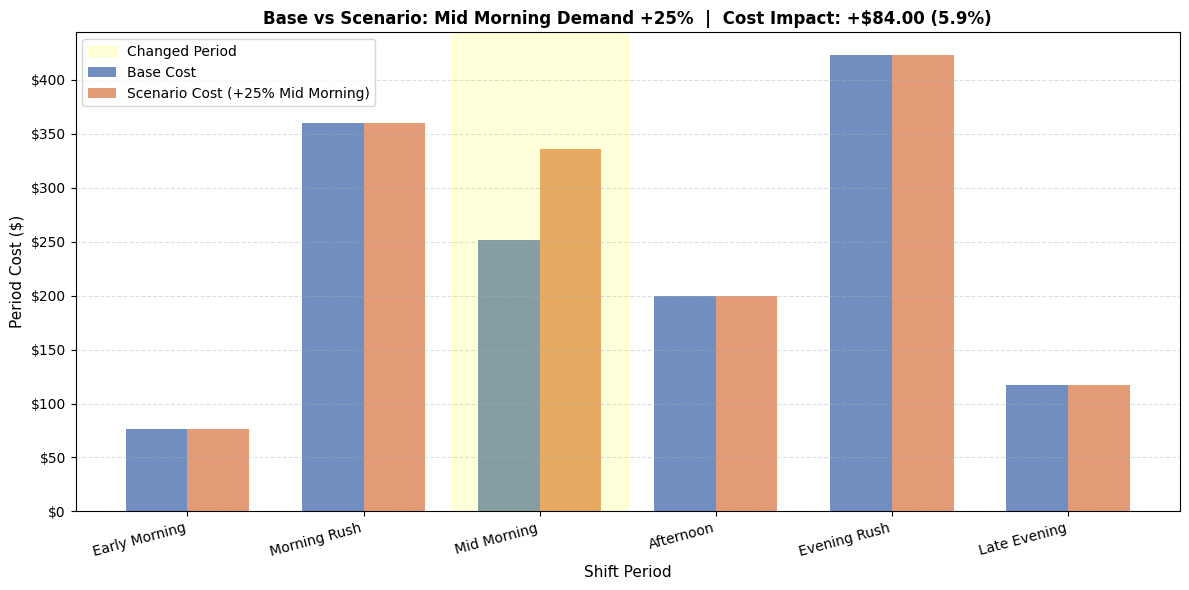

In [9]:
import copy

# --- What-If Scenario: Mid Morning demand increased by 25% ---
scenario_df = schedule_df.copy()
mid_morning  = "Mid Morning (8am-12pm)"

original_demand = scenario_df.loc[scenario_df["time_period"] == mid_morning, "demand_required"].values[0]
increased_demand = round(original_demand * 1.25)

scenario_df.loc[scenario_df["time_period"] == mid_morning, "demand_required"] = increased_demand

print(f"Scenario: Mid Morning demand increased from {original_demand} → {increased_demand} units (+25%)")

# Rebuild demand and capacity for scenario
demand_s = dict(zip(scenario_df["time_period"], scenario_df["demand_required"]))
cost_s   = dict(zip(scenario_df["time_period"], scenario_df["cost_per_unit"]))

scenario_capacity = int(scenario_df["demand_required"].sum() * 1.30)

# --- Scenario Model ---
scenario_model = LpProblem("Scheduling_Scenario", LpMinimize)
scheduled_s    = {p: LpVariable(f"sched_s_{p}", lowBound=0) for p in periods}

scenario_model += lpSum([scheduled_s[p] * cost_s[p] for p in periods]), "Total_Cost"

for p in periods:
    scenario_model += scheduled_s[p] >= demand_s[p], f"Coverage_{p}"

scenario_model += lpSum([scheduled_s[p] for p in periods]) <= scenario_capacity, "Total_Capacity"

scenario_model.solve(PULP_CBC_CMD(msg=0))

print(f"Scenario Model Status: {LpStatus[scenario_model.status]}")

# --- Build comparison dataframe ---
comparison_df = pd.DataFrame({
    "time_period":      periods,
    "demand_base":      [demand[p]   for p in periods],
    "demand_scenario":  [demand_s[p] for p in periods],
    "scheduled_base":   [value(active_scheduled[p]) for p in periods],
    "scheduled_scenario": [value(scheduled_s[p])    for p in periods],
    "cost_per_unit":    [cost[p] for p in periods],
    "period_cost_base": [round(value(active_scheduled[p]) * cost[p], 2) for p in periods],
    "period_cost_scenario": [round(value(scheduled_s[p])  * cost_s[p], 2) for p in periods],
})

comparison_df["cost_delta"] = (comparison_df["period_cost_scenario"]
                               - comparison_df["period_cost_base"]).round(2)

total_base     = comparison_df["period_cost_base"].sum()
total_scenario = comparison_df["period_cost_scenario"].sum()
total_delta    = total_scenario - total_base

display(comparison_df)
print(f"\nBase Total Cost:     ${total_base:,.2f}")
print(f"Scenario Total Cost: ${total_scenario:,.2f}")
print(f"Cost Increase:       ${total_delta:,.2f}  ({(total_delta/total_base)*100:.1f}%)")

# --- Comparison Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
x       = range(len(comparison_df))
labels  = [p.split("(")[0].strip() for p in comparison_df["time_period"]]
width   = 0.35

ax.bar([i - width/2 for i in x], comparison_df["period_cost_base"],
       width=width, color="#4C72B0", alpha=0.8, label="Base Cost")
ax.bar([i + width/2 for i in x], comparison_df["period_cost_scenario"],
       width=width, color="#DD8452", alpha=0.8, label="Scenario Cost (+25% Mid Morning)")

# Highlight the changed period
changed_idx = periods.index(mid_morning)
ax.axvspan(changed_idx - 0.5, changed_idx + 0.5, color="yellow", alpha=0.15, label="Changed Period")

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
ax.set_xlabel("Shift Period", fontsize=11)
ax.set_ylabel("Period Cost ($)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.title(f"Base vs Scenario: Mid Morning Demand +25%  |  Cost Impact: +${total_delta:,.2f} ({(total_delta/total_base)*100:.1f}%)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

The base schedule meets all delivery coverage requirements at the lowest possible cost with every shift is staffed to demand, with no excess crew and no gaps. When Mid Morning demand rises by 25% (from 6 to 8 units), the operation can still meet coverage by hiring two additional workers for that shift with an \$84 cost increase. The overall impact on that change is a 5.9% increase in cost impact. The tradeoff of tighter staffing keeps costs low but leaves no buffer for increased periods of hire demand, meaning even a modest demand spike in a single period translates straight into higher spending with no flexibility to absorb it elsewhere.

## Section 5 - Stakeholder Change and Reflection

The stakeholder made one change:
- Change objective from cost minimization to service maximization.


In [10]:
# --- Service Maximization Model ---
# Objective: maximize total scheduled coverage across all periods
# Budget constraint replaces capacity constraint as the binding limit

budget_limit = total_base * 1.20  # allow 20% more spend than base cost
print(f"Budget Limit (120% of base cost): ${budget_limit:,.2f}")

service_model  = LpProblem("Scheduling_Service_Max", LpMaximize)
scheduled_svc  = {p: LpVariable(f"sched_svc_{p}", lowBound=0) for p in periods}

# Objective: maximize total units scheduled (service coverage)
service_model += lpSum([scheduled_svc[p] for p in periods]), "Total_Coverage"

# Coverage floor: must still meet minimum demand in every period
for p in periods:
    service_model += scheduled_svc[p] >= demand[p], f"Min_Coverage_{p}"

# Budget ceiling: total spend cannot exceed budget limit
service_model += lpSum([scheduled_svc[p] * cost[p] for p in periods]) <= budget_limit, "Budget_Cap"

# Per-period cap: no single period scheduled beyond 2x its demand (operational realism)
for p in periods:
    service_model += scheduled_svc[p] <= demand[p] * 2, f"Period_Cap_{p}"

service_model.solve(PULP_CBC_CMD(msg=0))

print(f"Service Max Model Status: {LpStatus[service_model.status]}")

# --- Results ---
total_svc_cost     = sum(value(scheduled_svc[p]) * cost[p] for p in periods)
total_svc_units    = sum(value(scheduled_svc[p]) for p in periods)
total_base_units   = sum(value(active_scheduled[p]) for p in periods)

print(f"\nBase Model     — Total Units: {total_base_units:.0f}  |  Total Cost: ${total_base:,.2f}")
print(f"Service Max    — Total Units: {total_svc_units:.0f}  |  Total Cost: ${total_svc_cost:,.2f}")
print(f"Coverage Gain: +{total_svc_units - total_base_units:.0f} units  |  Cost Increase: +${total_svc_cost - total_base:,.2f}")

# --- Comparison DataFrame ---
service_compare_df = pd.DataFrame({
    "time_period":        periods,
    "demand_required":    [demand[p] for p in periods],
    "scheduled_base":     [value(active_scheduled[p]) for p in periods],
    "scheduled_svc_max":  [value(scheduled_svc[p]) for p in periods],
    "cost_per_unit":      [cost[p] for p in periods],
    "cost_base":          [round(value(active_scheduled[p]) * cost[p], 2) for p in periods],
    "cost_svc_max":       [round(value(scheduled_svc[p])    * cost[p], 2) for p in periods],
})
service_compare_df["extra_units"] = (service_compare_df["scheduled_svc_max"]
                                     - service_compare_df["scheduled_base"]).round(2)
display(service_compare_df)

Budget Limit (120% of base cost): $1,713.60
Service Max Model Status: Optimal

Base Model     — Total Units: 33  |  Total Cost: $1,428.00
Service Max    — Total Units: 40  |  Total Cost: $1,713.60
Coverage Gain: +7 units  |  Cost Increase: +$285.60


,time_period,demand_required,scheduled_base,scheduled_svc_max,cost_per_unit,cost_base,cost_svc_max,extra_units
0,Early Morning (12am-4am),2,2.0,4.000,38,76.0,152.0,2.00
1,Morning Rush (4am-8am),8,8.0,8.000,45,360.0,360.0,0.00
2,Mid Morning (8am-12pm),6,6.0,6.000,42,252.0,252.0,0.00
3,Afternoon (12pm-4pm),5,5.0,7.315,40,200.0,292.6,2.32
4,Evening Rush (4pm-8pm),9,9.0,9.000,47,423.0,423.0,0.00
5,Late Evening (8pm-12am),3,3.0,6.000,39,117.0,234.0,3.00


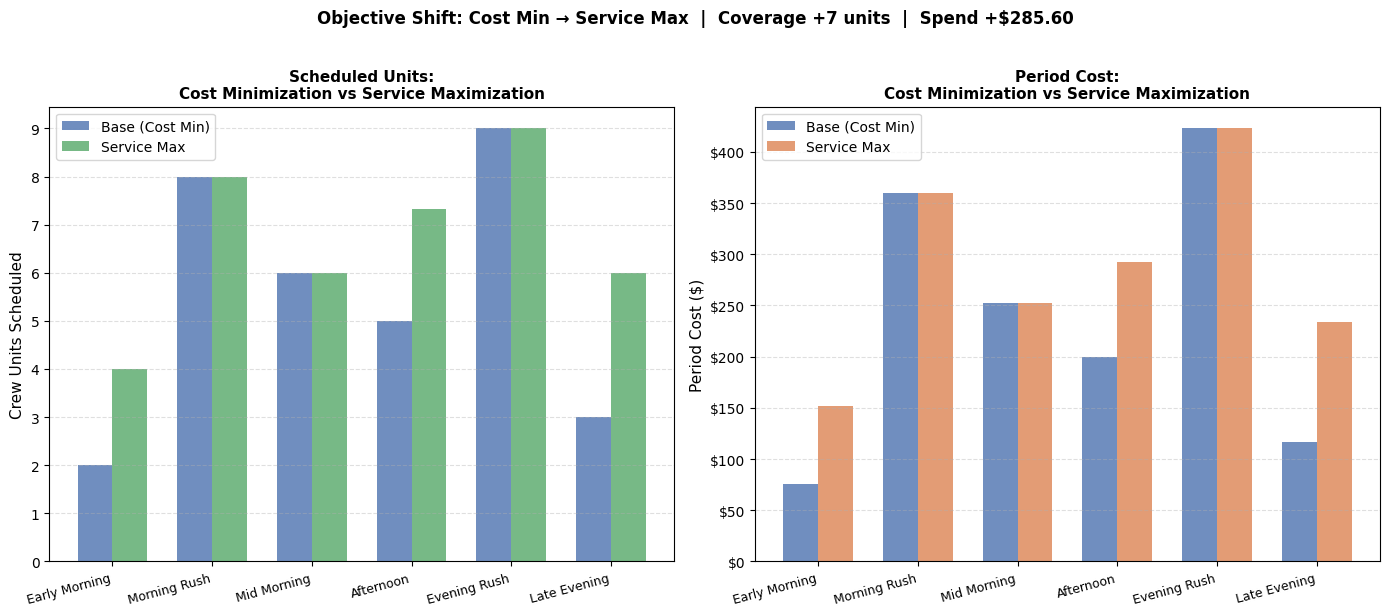

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels    = [p.split("(")[0].strip() for p in periods]
x         = range(len(periods))
width     = 0.35

# Left: scheduled units comparison
axes[0].bar([i - width/2 for i in x], service_compare_df["scheduled_base"],
            width=width, color="#4C72B0", alpha=0.8, label="Base (Cost Min)")
axes[0].bar([i + width/2 for i in x], service_compare_df["scheduled_svc_max"],
            width=width, color="#55A868", alpha=0.8, label="Service Max")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("Crew Units Scheduled", fontsize=11)
axes[0].set_title("Scheduled Units:\nCost Minimization vs Service Maximization", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Right: cost per period comparison
axes[1].bar([i - width/2 for i in x], service_compare_df["cost_base"],
            width=width, color="#4C72B0", alpha=0.8, label="Base (Cost Min)")
axes[1].bar([i + width/2 for i in x], service_compare_df["cost_svc_max"],
            width=width, color="#DD8452", alpha=0.8, label="Service Max")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
axes[1].set_ylabel("Period Cost ($)", fontsize=11)
axes[1].set_title("Period Cost:\nCost Minimization vs Service Maximization", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    f"Objective Shift: Cost Min → Service Max  |  "
    f"Coverage +{total_svc_units - total_base_units:.0f} units  |  "
    f"Spend +${total_svc_cost - total_base:,.2f}",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

### 5.1 Stakeholder Change Interpretation

When the goal changed from saving money to providing better service, the schedule started assigning more crew than the bare minimum in each time period. Instead of cutting costs as much as possible, it uses the available budget to add extra staff as a buffer so coverage is more reliable. The biggest increases happen during cheaper time periods like early morning and late evening, because that is where adding staff gives the most coverage for the lowest cost.

This matters for decision-making because it highlights the tradeoff of whether leadership cares more about saving money or increasing service. A cost-focused plan is cheaper but can break down when unexpected demand spikes happen, causing an increase in costs. A service-focused plan is more reliable because it builds in extra coverage, but it costs more on purpose. The key takeaway is that neither option is always best, and that deciding how much extra coverage is worth the additiona cost needs to be considered.

### 5.2 Professional Reflection

**Prompt:** Write a 2-3 paragraph professional reflection that covers:
- what changed in your model and results,
- why that change matters in your domain,
- and one thing you learned about how time-based scheduling constraints differ from earlier allocation problems.

Write this as if briefing a manager or project sponsor.

In this scenario the shift scheduling model changed from simply trying to spend as little as possible to focusing on providing better service, based on what the stakeholder wanted. At first, it assigned just enough crew to meet demand in each shift, which kept costs low but left no backup if something went wrong. When the goal shifted, the model started using extra budget to add backup staff—especially during cheaper time periods like late evening and overnight, where labor cost was lower. The what-if scenario also showed that even a small spike in demand (like a 25% increase in mid-morning) raises costs, proving that a bare-minimum plan did not allow for cost absorption in other areas.

This is important because choosing what the model aims to optimize is not just a technical choice but a business decision. A low-cost plan works when everything is predictable, but it can fall apart when demand changes, which happens often in real operations. A service-focused plan makes it clear how much extra reliability costs, helping managers decide how much they are willing to increase cost for more service oriented operations.

Another key lesson is how time-based scheduling is different from simpler planning problems. In this case, each time period stands only has staff allocated to a specific shift and cannot extend staff into two or more shifts to help cover unexpected demand in a different shift. Any flexibility has to be built in on purpose, like adding extra budget or setting minimum service levels, rather than happening naturally.